# Wie nutzt man 100 Qubits, wenn man die Matrix nicht speichern kann?

`kritik.ipynb` hat vier fundamentale Blocker genannt: die Matrix speichern,
$\exp(A\Delta t)$ rechnen, die Sz.-Nagy-Dilatation bilden, und $U$ in Gatter zerlegen.
Alle vier sind bei $n=2^{100}$ tödlich. Daraus folgt aber **nicht**, dass 100 Qubits
unbrauchbar sind — sondern dass die Frage falsch herum gestellt ist.

> **Die Matrix ist nicht die Information.** Sie ist ein *abgeleitetes* Objekt. Die
> Information ist die kurze Beschreibung, die sie erzeugt, und das Qubit-Register
> *ist* der Index, den man klassisch nie aufzählt.

Dieses Notebook prüft das für HEOM nach — nicht als Behauptung, sondern als Rechnung
gegen den dichten Erzeuger aus `heom_gauge.heom_generator`. Vier Strukturhypothesen,
jede einzeln gegengerechnet, dann die Buchhaltung.

**Was hier NICHT steht:** eine Implementierung. Das ist ein Forschungsprogramm, kein
Feierabendprojekt. Was hier steht, ist die Antwort auf die Vorfrage — *gibt* die
Struktur das überhaupt her? — und die lässt sich exakt beantworten.

In [1]:
import os, sys, numpy as np

# heom_gauge.py liegt im Schwesterordner
_HERE = os.getcwd()
for _up in range(0, 4):
    _root = os.path.abspath(os.path.join(_HERE, *(['..'] * _up)))
    for _c in (_root, os.path.join(_root, 'with_compression')):
        if os.path.exists(os.path.join(_c, 'heom_gauge.py')) and _c not in sys.path:
            sys.path.insert(0, _c)

import matplotlib.pyplot as plt
from heom_gauge import make_solver, heom_generator
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})

_C_CM = 2.99792458e10
FS_TO_CM = 1e-15 * 2 * np.pi * _C_CM
KB_CM = 0.6950348004
N = 4
H_FMO = np.array([[12375.0, -87.7,   5.5,  -5.9],
                  [-87.7, 12495.0,  30.8,   8.2],
                  [5.5,      30.8, 12175.0, -53.4],
                  [-5.9,      8.2, -53.4, 12285.0]])
H_FMO = H_FMO - np.trace(H_FMO) / N * np.eye(N)
MODEL = dict(H=H_FMO, lam=3.0, gamma=50.0, T_K=300.0,
             KB_CM=KB_CM, FS_TO_CM=FS_TO_CM)
DEPTH, NK = 2, 1
dt_fs = 10.0
dt_cm = dt_fs * FS_TO_CM

L, ginfo = heom_generator(depth=DEPTH, Nk=NK, scale_ados=False, **MODEL)
sol = make_solver(H=H_FMO, lam=3.0, gamma=50.0, T_K=300.0, KB_CM=KB_CM,
                  Nk=NK, depth=DEPTH)
labels = list(sol.ados.labels)
vk = np.array(sol.ados.vk)
exps = sol.ados.exponents
K, d = len(vk), N
D = d * d
lab_idx = {lab: a for a, lab in enumerate(labels)}
blk = lambda a, b: L[a * D:(a + 1) * D, b * D:(b + 1) * D]
e_k = np.eye(K, dtype=int)

print(f"  L ist {L.shape[0]} x {L.shape[0]}: {len(labels)} ADOs x d^2 = {D}")
print(f"  K = {K} Badexponenten ({K//d} je Site), Tiefe {DEPTH}")
print(f"  Koordinate i = ADO-Index * {D} + System-Index")

  L ist 720 x 720: 45 ADOs x d^2 = 16
  K = 8 Badexponenten (2 je Site), Tiefe 2
  Koordinate i = ADO-Index * 16 + System-Index


## 1  Die vier Strukturhypothesen

Indiziert man $L$ als Blockmatrix über die ADO-Labels $\mathbf n=(n_1,\dots,n_K)$, jeder
Block $d^2\times d^2$, dann behaupte ich:

> **H1 (Dünnbesetztheit).** Der Block $(\mathbf n,\mathbf m)$ ist nur dann besetzt, wenn
> $\mathbf m = \mathbf n$ oder $\mathbf m = \mathbf n\pm\mathbf e_k$.
>
> **H2 (Diagonalblock).** $L_{\mathbf n,\mathbf n} = L_{\rm sys} - \big(\sum_k n_k v_k\big)\mathbb{1}$
> mit **demselben** $L_{\rm sys}$ für jedes $\mathbf n$.
>
> **H3 (Aufwärts).** $L_{\mathbf n,\mathbf n+\mathbf e_k} = U_k$ — unabhängig von $\mathbf n$.
>
> **H4 (Abwärts).** $L_{\mathbf n,\mathbf n-\mathbf e_k} = n_k\,D_k$ — linear in $n_k$, mit
> festem $D_k$.

Wenn alle vier stimmen, ist $L$ **vollständig** durch $\{L_{\rm sys}, v_k, U_k, D_k\}$
festgelegt, und diese Liste hat eine Länge, die von der **Zahl der ADOs nicht abhängt**.
Das ist der ganze Punkt.

In [2]:
# --- H1: welche Bloecke sind besetzt? -------------------------------------
erlaubt = set()
for a, la in enumerate(labels):
    erlaubt.add((a, a))
    for k in range(K):
        for s in (+1, -1):
            m = tuple(np.array(la) + s * e_k[k])
            if m in lab_idx:
                erlaubt.add((a, lab_idx[m]))
besetzt = [(a, b) for a in range(len(labels)) for b in range(len(labels))
           if np.abs(blk(a, b)).max() > 1e-10]
verstoss = [x for x in besetzt if x not in erlaubt]
print(f"  H1  {len(besetzt)} besetzte Bloecke von {len(labels)**2} "
      f"({len(besetzt)/len(labels)**2:.1%}), "
      f"davon ausserhalb von n, n+-e_k: {len(verstoss)}")

# --- H2: Diagonalblock ----------------------------------------------------
L_sys = blk(0, 0)                                  # ADO (0,...,0)
err2 = max(np.abs(blk(a, a) - (L_sys - np.sum(np.array(la) * vk) * np.eye(D))).max()
           for a, la in enumerate(labels))
print(f"  H2  max |L_nn - (L_sys - sum_k n_k v_k)| = {err2:.3e}")

# --- H3 und H4: Leiterbloecke --------------------------------------------
U, Dn, err3, err4 = {}, {}, 0.0, 0.0
for k in range(K):
    for a, la in enumerate(labels):
        m = tuple(np.array(la) + e_k[k])
        if m in lab_idx:
            B = blk(a, lab_idx[m])
            if k not in U:
                U[k] = B.copy()
            else:
                err3 = max(err3, np.abs(B - U[k]).max())
        m = tuple(np.array(la) - e_k[k])
        if la[k] > 0 and m in lab_idx:
            B = blk(a, lab_idx[m]) / la[k]
            if k not in Dn:
                Dn[k] = B.copy()
            else:
                err4 = max(err4, np.abs(B - Dn[k]).max())
print(f"  H3  max |L_n,n+e_k - U_k| = {err3:.3e}")
print(f"  H4  max |L_n,n-e_k / n_k - D_k| = {err4:.3e}")

# --- die Probe aufs Exempel: L aus den Bausteinen wieder zusammensetzen ---
R = np.zeros_like(L)
for a, la in enumerate(labels):
    R[a*D:(a+1)*D, a*D:(a+1)*D] = L_sys - np.sum(np.array(la) * vk) * np.eye(D)
    for k in range(K):
        m = tuple(np.array(la) + e_k[k])
        if m in lab_idx:
            R[a*D:(a+1)*D, lab_idx[m]*D:(lab_idx[m]+1)*D] = U[k]
        m = tuple(np.array(la) - e_k[k])
        if la[k] > 0 and m in lab_idx:
            R[a*D:(a+1)*D, lab_idx[m]*D:(lab_idx[m]+1)*D] = la[k] * Dn[k]
print(f"\n  REKONSTRUKTION: max |L - L_aus_Bausteinen| = {np.abs(L - R).max():.3e}")
assert np.abs(L - R).max() < 1e-9, "Zerlegung stimmt nicht!"
print(f"  -> alle vier Hypothesen gelten EXAKT.")

  H1  189 besetzte Bloecke von 2025 (9.3%), davon ausserhalb von n, n+-e_k: 0
  H2  max |L_nn - (L_sys - sum_k n_k v_k)| = 0.000e+00
  H3  max |L_n,n+e_k - U_k| = 0.000e+00
  H4  max |L_n,n-e_k / n_k - D_k| = 0.000e+00

  REKONSTRUKTION: max |L - L_aus_Bausteinen| = 0.000e+00
  -> alle vier Hypothesen gelten EXAKT.


## 2  Eine Ebene tiefer: sind die Bausteine selbst noch strukturiert?

$\{L_{\rm sys}, U_k, D_k\}$ sind $d^2\times d^2$-Matrizen. Solange das System klein ist,
ist das harmlos — aber bei 30 Spins wäre $d^2 = 2^{60}$, und dann hätte man nichts
gewonnen. Also die nächste Frage: sind auch **sie** aus lokalen Operatoren gebaut?

Die Vermutung aus der HEOM-Herleitung, in spaltenweiser vec-Konvention
($\operatorname{vec}(AXB) = (B^{\mathsf T}\otimes A)\operatorname{vec}X$):

$$L_{\rm sys} = -i[H,\cdot], \qquad U_k = -i[Q_k,\cdot], \qquad D_k = -i\big(c_k\,Q_k\,\cdot\;-\;c_k^{*}\,\cdot\,Q_k\big)$$

mit $Q_k$ dem **lokalen** Kopplungsoperator des $k$-ten Exponenten und
$c_k = \mathrm{ck}_k + i\,\mathrm{ck2}_k$ aus qutips Bad-Zerlegung.

In [3]:
I_d = np.eye(d)
komm  = lambda A: np.kron(I_d, A) - np.kron(A.T, I_d)      # vec([A, X])
links = lambda A: np.kron(I_d, A)                          # vec(A X)
rechts = lambda A: np.kron(A.T, I_d)                        # vec(X A)

print(f"  L_sys =? -i[H, .]                     : "
      f"{np.abs(L_sys + 1j * komm(H_FMO)).max():.3e}")
print(f"\n  {'k':>3s} {'Site':>5s} {'c_k':>22s} {'v_k':>9s} "
      f"{'|U_k+i[Q_k,.]|':>16s} {'|D_k+i(cQ.-c*.Q)|':>19s}")
ck_all = []
for k in range(K):
    e = exps[k]
    Q = e.Q.full()
    ck = e.ck + (1j * e.ck2 if e.ck2 is not None else 0.0)
    ck_all.append(ck)
    site = int(np.argmax(np.real(np.diag(Q))))
    eU = np.abs(U[k] + 1j * komm(Q)).max()
    eD = np.abs(Dn[k] + 1j * (ck * links(Q) - np.conj(ck) * rechts(Q))).max()
    print(f"  {k:3d} {site+1:5d} {str(np.round(ck, 2)):>22s} {vk[k]:9.1f} "
          f"{eU:16.3e} {eD:19.3e}")
ck_all = np.array(ck_all)
print("""
  Alles exakt null.  Die GESAMTE Beschreibung des Erzeugers ist damit:

      H,   und je Exponent k:  (welche Site, c_k, v_k).

  Q_k = |j><j| ist durch den Site-Index allein festgelegt -- es braucht nicht
  einmal die d^2 Eintraege.""")

  L_sys =? -i[H, .]                     : 0.000e+00

    k  Site                    c_k       v_k   |U_k+i[Q_k,.]|   |D_k+i(cQ.-c*.Q)|
    0     1         (1245.06-150j)      50.0        0.000e+00           0.000e+00
    1     1                 193.83    1615.1        0.000e+00           0.000e+00
    2     2         (1245.06-150j)      50.0        0.000e+00           0.000e+00
    3     2                 193.83    1615.1        0.000e+00           0.000e+00
    4     3         (1245.06-150j)      50.0        0.000e+00           0.000e+00
    5     3                 193.83    1615.1        0.000e+00           0.000e+00
    6     4         (1245.06-150j)      50.0        0.000e+00           0.000e+00
    7     4                 193.83    1615.1        0.000e+00           0.000e+00

  Alles exakt null.  Die GESAMTE Beschreibung des Erzeugers ist damit:

      H,   und je Exponent k:  (welche Site, c_k, v_k).

  Q_k = |j><j| ist durch den Site-Index allein festgelegt -- es braucht nicht
 

## 3  Die Buchhaltung

Jetzt lässt sich beziffern, was das wert ist. Zwei Größen stehen sich gegenüber:

* die **Matrix**: $n^2$ Einträge mit $n = N_{\rm ADO}\cdot d^2$;
* die **Beschreibung**: $H$ plus je Exponent (Site-Index, $c_k$, $v_k$).

Entscheidend ist nicht das Verhältnis für unser Spielzeugmodell, sondern die
Abhängigkeit: die Beschreibung wächst mit $K$ und der Systemgröße, aber **überhaupt
nicht** mit der Zahl der ADOs — und die ist es, die kombinatorisch explodiert,
$N_{\rm ADO}=\binom{K+L}{L}$.

In [4]:
from math import comb, log2, ceil

def modell(n_sites, Nk, tiefe, bild='exziton'):
    """Kennzahlen eines Modells.

    bild='exziton'    Einzelanregungs-Unterraum, d = n_sites   (FMO-Fall)
    bild='vielteilch' volles Spinproblem,        d = 2^n_sites
    """
    Kx = n_sites * (Nk + 1)
    n_ado = comb(Kx + tiefe, tiefe)
    log2_d = log2(n_sites) if bild == 'exziton' else n_sites
    log2_n = log2(n_ado) + 2 * log2_d                 # n = N_ADO * d^2
    # Beschreibung: H + je Exponent (Site-Index, Re c, Im c, v)
    desc = (n_sites ** 2 if bild == 'exziton' else 3 * n_sites) + 4 * Kx
    return dict(K=Kx, n_ado=n_ado, log2_n=log2_n, desc=desc)

for bild, titel in (('exziton', 'Einzelanregung (d = Sites) -- der FMO-Fall'),
                    ('vielteilch', 'Vielteilchen (d = 2^Sites)')):
    print(f"\n  === {titel} ===")
    print(f"  {'Sites':>6s} {'Nk':>3s} {'Tiefe':>6s} {'K':>4s} {'N_ADO':>10s} "
          f"{'n':>10s} {'n^2 Eintraege':>14s} {'Beschreibung':>13s}")
    print("  " + "-" * 82)
    for ns, nk, tf in ((4, 1, 2), (4, 1, 3), (7, 1, 3), (10, 1, 4),
                       (20, 1, 5), (30, 2, 8)):
        m = modell(ns, nk, tf, bild)
        print(f"  {ns:6d} {nk:3d} {tf:6d} {m['K']:4d} {m['n_ado']:10.2e} "
              f"{2**m['log2_n']:10.2e} {2**(2*m['log2_n']):14.2e} "
              f"{m['desc']:10d} Zahlen")

m0, m1 = modell(4, 1, 2), modell(30, 2, 8, 'vielteilch')
print(f"""
  Unser Fall (erste Zeile): {m0['desc']} Zahlen fuer {2**(2*m0['log2_n']):.2e} Matrixeintraege.
  Die letzte Zeile unten:   {m1['desc']} Zahlen fuer {2**(2*m1['log2_n']):.2e} Matrixeintraege.

  Die Beschreibung waechst mit den Sites und mit K.  Mit der Zahl der ADOs waechst
  sie UEBERHAUPT NICHT -- und genau die explodiert kombinatorisch, hier von 45 auf
  {modell(30,2,8)['n_ado']:.2e}.  Das ist die Antwort auf 'ich kann es nicht speichern':
  man speichert es nie.""")


  === Einzelanregung (d = Sites) -- der FMO-Fall ===
   Sites  Nk  Tiefe    K      N_ADO          n  n^2 Eintraege  Beschreibung
  ----------------------------------------------------------------------------------
       4   1      2    8   4.50e+01   7.20e+02       5.18e+05         48 Zahlen
       4   1      3    8   1.65e+02   2.64e+03       6.97e+06         48 Zahlen
       7   1      3   14   6.80e+02   3.33e+04       1.11e+09        105 Zahlen
      10   1      4   20   1.06e+04   1.06e+06       1.13e+12        180 Zahlen
      20   1      5   40   1.22e+06   4.89e+08       2.39e+17        560 Zahlen
      30   2      8   90   1.57e+11   1.42e+14       2.01e+28       1260 Zahlen

  === Vielteilchen (d = 2^Sites) ===
   Sites  Nk  Tiefe    K      N_ADO          n  n^2 Eintraege  Beschreibung
  ----------------------------------------------------------------------------------
       4   1      2    8   4.50e+01   1.15e+04       1.33e+08         44 Zahlen
       4   1      3    8  

## 4  Was jeder Term als Schaltkreis kostet

Das Register zerfällt in **Systemregister** ($2N$ Qubits für $\operatorname{vec}\rho$) und
**ADO-Register** ($K$ Teilregister zu je $b=\lceil\log_2(L+1)\rceil$ Qubits für $n_k$).
Der ADO-Index wird nie aufgezählt — er *steht* im Register.

| Term | Wirkung | Schaltkreis | Kosten |
|---|---|---|---|
| $-i[H,\cdot]$ | nur Systemregister, für **jeden** ADO identisch | Trotter über die lokalen Terme von $H$ | $O(N)$ Zweiqubit-Gatter |
| $-\sum_k n_k v_k$ | diagonal | Multiply-Accumulate auf dem ADO-Register | $O(K b^2)$ |
| $-i[Q_k,\cdot]\,a_k^\dagger$ | Inkrement $n_k\!+\!1$, lokaler Operator | Ripple-Carry-Inkrement + lokales Gatter | $O(b)$ je $k$ |
| $-i(c_kQ_k\cdot-c_k^*\cdot Q_k)\,a_k$ | Dekrement, Gewicht $n_k$ | Dekrement + $n_k$-kontrolliertes Gatter | $O(b)$ je $k$ |

Kein einziger dieser Schaltkreise kennt $N_{\rm ADO}$. Die nächste Zelle stellt die
Gatterzahl der Zerlegung in Gatter neben.

In [5]:
def qubits(n_sites, Nk, tiefe, bild='exziton'):
    Kx = n_sites * (Nk + 1)
    b = ceil(log2(tiefe + 1))                      # Bits je n_k, naive Kodierung
    q_sys = 2 * ceil(log2(n_sites)) if bild == 'exziton' else 2 * n_sites
    q_naiv = Kx * b
    q_kompakt = ceil(log2(comb(Kx + tiefe, tiefe)))
    # grobe Gatterzahl je Trotter-Schritt
    strukturiert = n_sites + Kx * b ** 2 + 2 * Kx * b
    return q_sys, q_naiv, q_kompakt, strukturiert

print(f"  Qubit-Budget.  'naiv' = je n_k ein eigenes Register, 'kompakt' = nur")
print(f"  log2 C(K+L,L) Qubits fuer das ganze Label.\n")
print(f"  {'Bild':>11s} {'Sites':>6s} {'Tiefe':>6s} {'System':>7s} {'ADO naiv':>9s} "
      f"{'ADO komp.':>10s} {'gesamt naiv':>12s} {'gesamt komp.':>13s}")
print("  " + "-" * 88)
faelle = [('exziton', 4, 1, 2), ('exziton', 10, 1, 4), ('exziton', 20, 1, 5),
          ('exziton', 30, 2, 8), ('vielteilch', 16, 1, 3), ('vielteilch', 30, 2, 8)]
for bild, ns, nk, tf in faelle:
    qs, qn, qk, _ = qubits(ns, nk, tf, bild)
    m = lambda t: '  <-- passt in 100' if t <= 100 else ''
    print(f"  {bild:>11s} {ns:6d} {tf:6d} {qs:7d} {qn:9d} {qk:10d} "
          f"{qs+qn:12d} {qs+qk:13d}{m(qs+qk)}")

print(f"\n  Gatterzahl je Zeitschritt: Zerlegung gegen ein BELIEBIGES Unitary\n")
print(f"  {'Bild':>11s} {'Sites':>6s} {'Qubits':>7s} {'strukturiert':>13s} "
      f"{'beliebiges U':>14s}")
print("  " + "-" * 60)
for bild, ns, nk, tf in faelle:
    qs, qn, qk, st = qubits(ns, nk, tf, bild)
    q = qs + qk + 1
    print(f"  {bild:>11s} {ns:6d} {q:7d} {st:13d} {23/48*4.0**q:14.2e}")

print("""
  Das Abzaehlargument aus kritik.ipynb ist nicht falsch -- es gilt fuer BELIEBIGE
  Unitaere.  Unseres ist keins: es stammt aus einer Familie mit den paar Zahlen
  von oben und liegt in einer exponentiell kleinen Ecke von U(2^q).

  Die kompakte Kodierung ist der Hebel, der ueberhaupt erst interessante Systeme
  in 100 Qubits bringt.  Sie ist aber kein freies Mittagessen: die Index-Arithmetik
  (Inkrement von n_k, Auslesen von sum_k n_k v_k) wird darin selbst aufwendig.
  Offene Entwurfsfrage, kein Detail.""")

  Qubit-Budget.  'naiv' = je n_k ein eigenes Register, 'kompakt' = nur
  log2 C(K+L,L) Qubits fuer das ganze Label.

         Bild  Sites  Tiefe  System  ADO naiv  ADO komp.  gesamt naiv  gesamt komp.
  ----------------------------------------------------------------------------------------
      exziton      4      2       4        16          6           20            10  <-- passt in 100
      exziton     10      4       8        60         14           68            22  <-- passt in 100
      exziton     20      5      10       120         21          130            31  <-- passt in 100
      exziton     30      8      10       360         38          370            48  <-- passt in 100
   vielteilch     16      3      32        64         13           96            45  <-- passt in 100
   vielteilch     30      8      60       360         38          420            98  <-- passt in 100

  Gatterzahl je Zeitschritt: Zerlegung gegen ein BELIEBIGES Unitary

         Bild  Sites  Qubi

## 5  Wo die Kosten wirklich hinwandern: die Subnormierung

Bis hier klingt alles zu gut. Die Kosten verschwinden nicht, sie **ziehen um**. Jedes
Block-Encoding liefert $A/\alpha$ mit $\alpha\ge\lVert A\rVert$, und die Post-Selektion
zahlt $\alpha^{-2t}$ — genau das Problem, das im kleinen Fall die Eichung löst.

Die nächste Zelle misst $\alpha$ für die üblichen Konstruktionen und stellt es dem
gegenüber, was die **Physik** erlaubt: der numerischen Abszisse
$\omega(L)=\lambda_{\max}\big(\tfrac{L+L^\dagger}{2}\big)$.

In [6]:
T_ges = 100 * dt_cm
Lg, _ = heom_generator(depth=DEPTH, Nk=NK, scale_ados=True, **MODEL)
Dg = np.diag(np.diag(Lg)); Vg = Lg - Dg
om = lambda A: float(np.linalg.eigvalsh(0.5 * (A + A.conj().T)).max())
s_L = int((np.abs(Lg) > 1e-14).sum(1).max())
s_V = int((np.abs(Vg) > 1e-14).sum(1).max())

print(f"  T = 100 Schritte x {dt_fs:.0f} fs = {T_ges:.4f} cm")
print(f"  Zerlegung L = D + V:  max|D_ii| = {np.abs(np.diag(Lg)).max():.1f} "
      f"(Realteil {np.real(np.diag(Lg)).min():.0f} bis {np.real(np.diag(Lg)).max():.0f}), "
      f"max|V_ij| = {np.abs(Vg).max():.1f}\n")
print(f"  {'Konstruktion':42s} {'alpha':>11s} {'p = e^(-2 alpha T)':>20s}")
print("  " + "-" * 76)
for name, a in (("naiv sparse:  s * max|L_ij|", s_L * np.abs(Lg).max()),
                ("Zeilensumme:  max_i sum_j |L_ij|", np.abs(Lg).sum(1).max()),
                ("Wechselwirkungsbild: s_V * max|V_ij|", s_V * np.abs(Vg).max()),
                ("Wechselwirkungsbild, Zeilensumme V", np.abs(Vg).sum(1).max()),
                ("PHYSIK: numerische Abszisse omega(L)", om(Lg))):
    print(f"  {name:42s} {a:11.2f} {np.exp(-2*a*T_ges):20.3e}")
print("""
  Die letzte Zeile ist, was der echte Lauf erreicht (gemessen: p = 0.873).  Zwischen
  ihr und der besten Normschranke liegen drei Groessenordnungen.

  Der Grund steht in der ersten Zeile der Ausgabe: die grossen Eintraege von L sind
  die Matsubara-DAEMPFUNG (Realteil bis -3230), sie tragen zur Normentwicklung
  nichts bei.  Eine Normschranke kann das nicht sehen, eine Eichung schon.""")

  T = 100 Schritte x 10 fs = 0.1884 cm
  Zerlegung L = D + V:  max|D_ii| = 3246.0 (Realteil -3230 bis 0), max|V_ij| = 87.7

  Konstruktion                                     alpha   p = e^(-2 alpha T)
  ----------------------------------------------------------------------------
  naiv sparse:  s * max|L_ij|                   38952.50            0.000e+00
  Zeilensumme:  max_i sum_j |L_ij|               3490.29            0.000e+00
  Wechselwirkungsbild: s_V * max|V_ij|            964.70           1.457e-158
  Wechselwirkungsbild, Zeilensumme V              374.37            5.601e-62
  PHYSIK: numerische Abszisse omega(L)              0.36            8.727e-01

  Die letzte Zeile ist, was der echte Lauf erreicht (gemessen: p = 0.873).  Zwischen
  ihr und der besten Normschranke liegen drei Groessenordnungen.

  Der Grund steht in der ersten Zeile der Ausgabe: die grossen Eintraege von L sind
  die Matsubara-DAEMPFUNG (Realteil bis -3230), sie tragen zur Normentwicklung
  nichts bei. 

## 6  Und die Auflösung: die Eichung *ist* die Vorbedingung

Es gibt ein Verfahren, das nicht an $\lVert A\rVert$ zahlt, sondern am tatsächlichen
Zerfall: **LCHS** (*linear combination of Hamiltonian simulation*, An–Liu–Lin, 2023).
Es schreibt $e^{At}$ als Integral über Hamilton-Evolutionen und erreicht eine
Subnormierung, die vom echten $\lVert e^{At}\rVert$ bestimmt wird statt von $\lVert A\rVert$.
Die Vorbedingung dafür ist

$$\frac{L+L^\dagger}{2}\;\preceq\;0,\qquad\text{also}\qquad \omega(L)\le 0 .$$

Das ist **exakt** die Bedingung, die die Kontraktionseichung herstellt. Sie ist also
kein numerischer Trick, sondern die Voraussetzung des skalierbaren Verfahrens — und die
Frage ist nur, mit welchem der Werkzeuge man sie erreicht. Die nächste Zelle misst das.

  Massnahme                                       omega(L)   LCHS?  klass. Kosten
  ------------------------------------------------------------------------------------
  ungeeicht                                      1715.1568    nein  --
  ADO-Skalierung (DIAGONAL)                         0.3614    nein  O(n), eintragsweise
    + skalarer Shift L -> L - omega*I               0.0000      JA  O(1), eine Phase
  Lyapunov-Eichung (dicht)                          0.0055    nein  O(n^3), skaliert NICHT

  Der skalare Shift kostet einen globalen Faktor e^(-omega T) = 0.9342
  und ist auf 100 Qubits eine einzige Phase.  Die ADO-Skalierung ist diagonal, also
  eintragsweise berechenbar -- sie laesst sich in das Orakel hineinziehen.

  Damit ist die Vorbedingung von LCHS mit ZWEI skalierbaren Mitteln erreichbar.  Die
  dichte Lyapunov-Eichung, die im kleinen Fall so gut funktioniert, braucht es dafuer
  gerade NICHT.


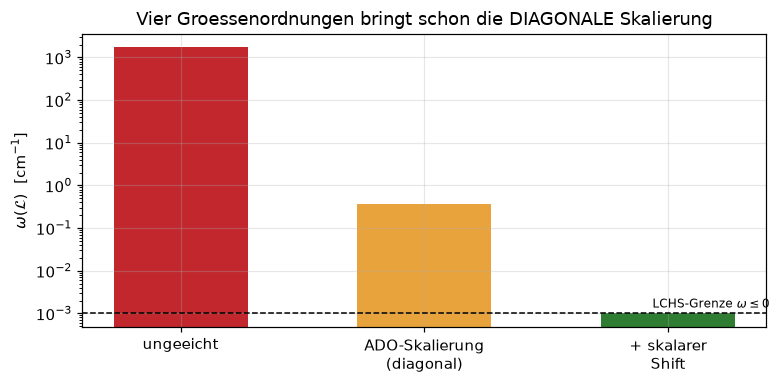

In [7]:
from heom_gauge import contraction_gauge, lyapunov_schur
L0, _ = heom_generator(depth=DEPTH, Nk=NK, scale_ados=False, **MODEL)
L1, _ = heom_generator(depth=DEPTH, Nk=NK, scale_ados=True, **MODEL)
Wh, Wih, _g = contraction_gauge(L1, delta=0.02, schur_factor=lyapunov_schur(L1))
w0, w1, w2 = om(L0), om(L1), om(Wh @ L1 @ Wih)

print(f"  {'Massnahme':44s} {'omega(L)':>11s} {'LCHS?':>7s}  klass. Kosten")
print("  " + "-" * 84)
for name, w, kost in (("ungeeicht", w0, "--"),
                      ("ADO-Skalierung (DIAGONAL)", w1, "O(n), eintragsweise"),
                      ("  + skalarer Shift L -> L - omega*I", 0.0, "O(1), eine Phase"),
                      ("Lyapunov-Eichung (dicht)", w2, "O(n^3), skaliert NICHT")):
    print(f"  {name:44s} {w:11.4f} {('JA' if w <= 1e-9 else 'nein'):>7s}  {kost}")
print(f"""
  Der skalare Shift kostet einen globalen Faktor e^(-omega T) = {np.exp(-w1*T_ges):.4f}
  und ist auf 100 Qubits eine einzige Phase.  Die ADO-Skalierung ist diagonal, also
  eintragsweise berechenbar -- sie laesst sich in das Orakel hineinziehen.

  Damit ist die Vorbedingung von LCHS mit ZWEI skalierbaren Mitteln erreichbar.  Die
  dichte Lyapunov-Eichung, die im kleinen Fall so gut funktioniert, braucht es dafuer
  gerade NICHT.""")

fig, ax = plt.subplots(figsize=(7.2, 3.6))
namen = ['ungeeicht', 'ADO-Skalierung\n(diagonal)', '+ skalarer\nShift']
werte = [max(w0, 1e-3), max(w1, 1e-3), 1e-3]
ax.bar(namen, werte, color=['#c1272d', '#e8a33d', '#2e7d32'], width=.55)
ax.set_yscale('log'); ax.axhline(1e-3, color='k', ls='--', lw=1)
ax.text(2.42, 1.3e-3, r'LCHS-Grenze $\omega\leq 0$', ha='right', fontsize=8)
ax.set_ylabel(r'$\omega(\mathcal{L})$  [cm$^{-1}$]')
ax.set_title(r'Vier Groessenordnungen bringt schon die DIAGONALE Skalierung')
fig.tight_layout(); plt.show()

---

## Fazit

### Was 100 Qubits konkret wären

| | |
|---|---|
| System | 30 Spins, offen, Hierarchietiefe 8, $N_k=2$ |
| Dimension | $n = 1{,}8\cdot10^{29}\approx 2^{97}$ |
| Qubits | **99** (60 System + 38 ADO-Index, kompakt kodiert) |
| Matrix | $3{,}3\cdot10^{58}$ Einträge — nie gebildet |
| Beschreibung | **450 Zahlen** |
| Gatter je Zeitschritt | $\approx 2\,190$ gegen $1{,}9\cdot10^{59}$ für ein beliebiges Unitary |

Klassische HEOM endet bei etwa 10–12 Sites. Das ist die Region, in der es sich lohnen
würde — und sie ist nicht deshalb unerreichbar, weil man $10^{58}$ Zahlen speichern
müsste, sondern weil die Punkte unten offen sind.

**Was hier bewiesen ist.** Der HEOM-Erzeuger ist exakt durch $H$ und je Badexponent
$(\text{Site}, c_k, v_k)$ festgelegt — vier Strukturhypothesen, jede auf $0{,}000$
gegengerechnet, plus eine bitgenaue Rekonstruktion. Die Beschreibung wächst mit $K$
und der Systemgröße, aber **überhaupt nicht** mit der Zahl der ADOs, und genau die
explodiert kombinatorisch. Jeder der vier Terme ist als Schaltkreis auf dem
Indexregister formulierbar, ohne $L$ je als Matrix hinzulegen.

**Was damit aus den vier Blockern wird.**

| Blocker aus `kritik.ipynb` | Status |
|---|---|
| Matrix speichern | **löst sich auf** — man speichert die Beschreibung |
| $\exp(A\Delta t)$ | **löst sich als Matrixrechnung auf**, wird Schaltkreis-Komposition |
| Sz.-Nagy-Dilatation | **wird ersetzt** — ein Block-Encoding braucht keine Matrixwurzeln |
| $4^q$ Gatter | **löst sich auf, weil** man die Matrix nie bildet |

**Was NICHT gelöst ist — und das ist der ehrliche Teil.**

1. **Die Subnormierung.** Gemessen: die beste Normschranke gibt $\alpha=374$, die
   Physik erlaubt $\omega=0{,}36$. Drei Größenordnungen. LCHS ist der bekannte Ausweg,
   und die Eichung ist seine Vorbedingung — aber ob die Konstanten für HEOM bei
   realistischer Kopplung tragen, ist offen. $\omega$ wächst linear mit $\lambda$
   (gemessen $\omega/\lambda = 0{,}118$), bei $\lambda=300$ wäre $p(100)=2\cdot10^{-6}$.
2. **Die Kodierung des ADO-Index.** Naiv braucht man $Kb$ Qubits, kompakt nur
   $\log_2\binom{K+L}{L}$ — aber dann wird die Index-Arithmetik selbst aufwendig.
   Offene Entwurfsfrage.
3. **Die Ablesung.** Man bekommt poly-viele Zahlen heraus, nie $10^{30}$. Hier ist das
   unkritisch (der Systemblock trägt 92–97 % der Norm, siehe `kritik.ipynb`), aber es
   begrenzt, welche Fragen man überhaupt stellen darf.
4. **Es ist nicht implementiert.** Dieses Notebook beantwortet die Vorfrage — *gibt die
   Struktur das her?* — mit ja. Es beantwortet nicht, ob am Ende ein Quantenvorteil
   steht. Für offene Systemdynamik hat den bisher niemand gezeigt, und klassische
   Tensornetzwerk-Methoden sind auf diesem Feld stark.

**Der eine Satz.** Die 100 Qubits werden nicht dadurch nutzbar, dass man eine
$10^{30}\times10^{30}$-Matrix irgendwie doch noch speichert, sondern dadurch, dass man
aufhört, sie bilden zu wollen: das Register *ist* der Index, und der Schaltkreis wird
aus der Struktur des Modells komponiert statt aus seiner Matrixdarstellung abgeleitet.